In [1]:
#from data import load_data
%load_ext autoreload
%autoreload 2
import numpy as np
import json
import os
import matplotlib.pyplot as plt

In [2]:
embeddings = np.load('logs/2026_6_24/3/embeddings.npy')
print(embeddings.shape)

(19391, 20)


Text(0.5, 1.0, 'Training loss')

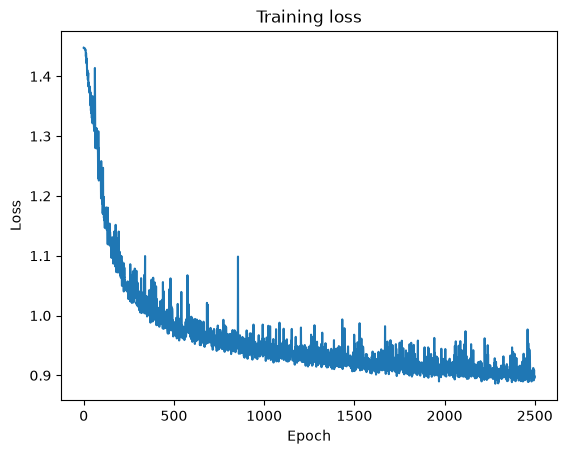

In [3]:
with open(os.path.join("logs/2026_6_24/3", 'metrics.json'), 'r') as f:
    results = json.load(f)

plt.plot(results['train_losses'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')

Text(0, 0.5, 'MAP')

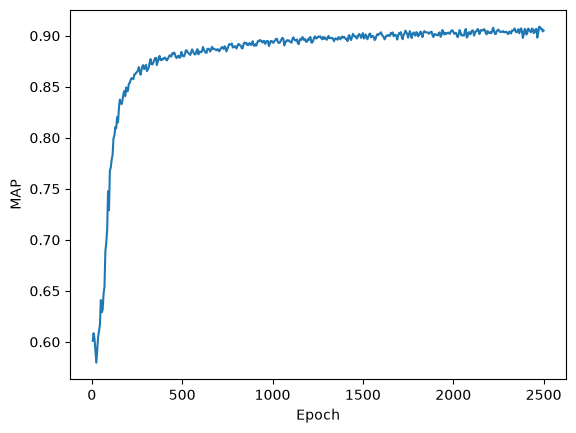

In [4]:
epochs = [m['epoch'] for m in results['val_metrics']]
maps = [m['ap'] for m in results['val_metrics']]  # ou 'ap' selon ce que retourne compute_metrics

plt.plot(epochs, maps)
plt.xlabel('Epoch')
plt.ylabel('MAP')

Text(0.5, 1.0, 'Distribution des normes dans B^n')

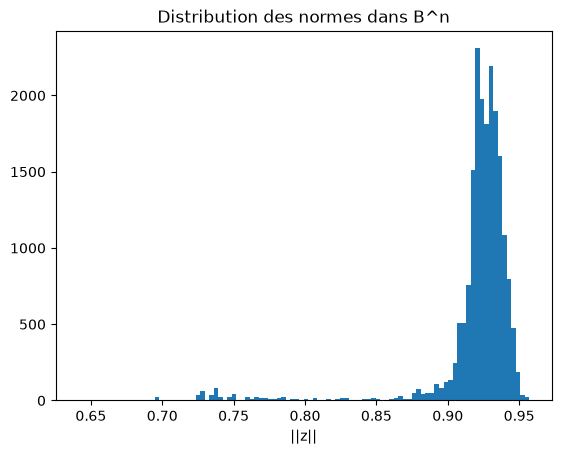

In [5]:
norms = np.linalg.norm(embeddings, axis=1)

plt.hist(norms, bins=100)
plt.xlabel('||z||')
plt.title('Distribution des normes dans B^n')

In [3]:
import OT
import poincare
import load_data as ld
import data

manifold = poincare.PoincareManifold()
nodes = list(ld.G_hpo_work.nodes())
node2idx = {n: i for i, n in enumerate(nodes)}

w_omim = ld.work_omim.reset_index(drop=True)
w_orpha = ld.work_orpha.reset_index(drop=True)
hpo_cols = [c for c in w_omim.columns if c.startswith('HP')]

ancestors = {hp: data.get_ancestors0(ld.G_hpo_work, hp) for hp in hpo_cols}
w_omim_P = data.propagate_terms(w_omim,  hpo_cols, ancestors, ld.depths, k=3)
w_orpha_P = data.propagate_terms(w_orpha, hpo_cols, ancestors, ld.depths, k=3)

union_diseases = data.add_corresponding_terms(w_omim, w_orpha, ld.df_orpha_omim_exact)
S = data.node_similarity_score(union_diseases, ld.G_hpo_work)

gt_set, valid_omim, valid_orpha = OT.f_ground_truth(w_omim, w_orpha, ld.df_orpha_omim_exact)

/home/onyxia/work/OT_simulation_maladies/HGCN/load_data.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()
Fusion HPO: 100%|██████████| 2237/2237 [00:00<00:00, 8280.80it/s]


In [4]:
C = OT.compute_costs_matrix_wasserstein2(w_omim, w_orpha, node2idx, embeddings, manifold, c=1., S=S)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 84/84 [00:40<00:00,  2.07it/s]


HPO distance matrix: (10649, 10649)


OMIM: 100%|██████████| 6562/6562 [21:45<00:00,  5.03it/s]


In [ ]:
C_gromov = OT.compute_costs_matrix_wasserstein2(w_omim, w_orpha, node2idx, embeddings, manifold, c=1., S=S, gromov=True)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 84/84 [00:40<00:00,  2.09it/s]


HPO distance matrix: (10649, 10649)


OMIM:  29%|██▉       | 1935/6562 [28:50<1:25:15,  1.11s/it]

In [10]:
# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_batch, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C_batch)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_batch)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C_batch, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C_batch)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.451 (1009/2237)
Top-3 accuracy : 0.481 (1077/2237)
Top-5 accuracy : 0.482 (1079/2237)
 Rang moyen: 840.52
======== Avec régularisation ========
0.03085278551987928
Paires évaluées : 2237
Top-1 accuracy : 0.455 (1017/2237)
Top-3 accuracy : 0.600 (1342/2237)
Top-5 accuracy : 0.653 (1461/2237)
 Rang moyen: 51.87


In [8]:
C_batch = OT.compute_costs_matrix_wasserstein_batched(w_omim, w_orpha, node2idx, embeddings, manifold, c=1., S=S)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 84/84 [00:39<00:00,  2.14it/s]


HPO distance matrix: (10649, 10649)
125 tailles distinctes côté OMIM, 117 côté Orpha


Length groups (OMIM): 100%|██████████| 125/125 [13:41<00:00,  6.57s/it]


In [ ]:
# Pondération des maladies
import pandas as pd
import data

all_diseases =pd.concat([ld.work_omim, ld.work_orpha], ignore_index=True)
w, _, _ = OT.compute_information_content(all_diseases, ld.G_hpo_work)

n, m = len(ld.work_omim), len(ld.work_orpha)

def precompute(df):
    '''
    Renvoie pour chaque maladie (ligne) du dataframe df la liste des termes HPO actifs et 
    le vecteur de poids uniformes associés.
    '''
    hpo_cols = [c for c in df.columns if c.startswith('HP')]
    X = df[hpo_cols].to_numpy(dtype=bool)
    resolved_cols = np.array(
        [data.deprecated.get(col, col) if data.deprecated.get(col, col) in ld.node2id_w else None for col in hpo_cols], 
        dtype=object)
    valid_mask = resolved_cols != np.array(None)
    X_valid = X[:, valid_mask]
    resolved_valid = resolved_cols[valid_mask]
    terms = [list(resolved_valid[row_mask]) for row_mask in X_valid]
    return terms

active_omim = precompute(ld.work_omim)
active_orpha = precompute(ld.work_orpha)
def precompute_weights(active, w):
    ic  = {k:-np.log(t) for k,t in w.items()}
    a0 = np.zeros(len(active))
    a1 = np.zeros(len(active))
    for j in range(len(active)):
        terms = active[j]
        w_j = np.array([w[t] for t in terms])
        ic_j = np.array([ic[t] for t in terms])
        a0[j], a1[j] = np.mean(w_j), np.mean(ic_j)
    return a0/a0.sum(), a1/a1.sum()

a_omim, ic_omim = precompute_weights(active_omim, w)
b_orpha, ic_orpha = precompute_weights(active_orpha, w)

6562 6562
3189 3189


In [46]:
# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C, ic_omim, ic_orpha)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C, ic_omim, ic_orpha, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.378 (846/2237)
Top-3 accuracy : 0.413 (924/2237)
Top-5 accuracy : 0.414 (925/2237)
 Rang moyen: 944.62
======== Avec régularisation ========
0.11578572626100278
Paires évaluées : 2237
Top-1 accuracy : 0.397 (887/2237)
Top-3 accuracy : 0.517 (1156/2237)
Top-5 accuracy : 0.558 (1249/2237)
 Rang moyen: 86.57


In [12]:
# Pondération des termes dans le double transport
import pandas as pd

all_diseases =pd.concat([ld.work_omim, ld.work_orpha], ignore_index=True)

w, _, _ = OT.compute_information_content(all_diseases, ld.G_hpo_work)
ic = {k:-np.log(t) for k,t in w.items()}

#C_ic = OT.compute_costs_matrix_wasserstein2(ld.work_omim, ld.work_orpha, node2idx, embeddings, manifold, c=1., weights=ic)

In [9]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_ic, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C_ic)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_ic)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C_ic, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C_ic)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.362 (810/2237)
Top-3 accuracy : 0.400 (895/2237)
Top-5 accuracy : 0.401 (898/2237)
 Rang moyen: 964.39
======== Avec régularisation ========
0.12026577286673287
Paires évaluées : 2237
Top-1 accuracy : 0.395 (884/2237)
Top-3 accuracy : 0.511 (1144/2237)
Top-5 accuracy : 0.563 (1260/2237)
 Rang moyen: 87.14


In [20]:
# Transport entre barycentres
C_bary = OT.compute_costs_barycenter(
    ld.work_omim, ld.work_orpha, node2idx, embeddings, data.deprecated, manifold)

print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_bary, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set, C_bary)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_bary)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C_bary, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set, C_bary)

Barycentres: 100%|██████████| 3189/3189 [01:34<00:00, 33.92it/s]


======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.028 (63/2237)
Top-3 accuracy : 0.037 (83/2237)
Top-5 accuracy : 0.039 (88/2237)
 Rang moyen: 1566.46
======== Avec régularisation ========
0.2809487846644238
Paires évaluées : 2237
Top-1 accuracy : 0.028 (63/2237)
Top-3 accuracy : 0.065 (146/2237)
Top-5 accuracy : 0.096 (215/2237)
 Rang moyen: 254.18


In [ ]:
work_omim0 = ld.work_omim[ld.work_omim['database_id'].isin(valid_omim)]
work_orpha0 = ld.work_orpha[ld.work_orpha['database_id'].isin(valid_orpha)]
work_omim0 = work_omim0.reset_index(drop=True)
work_orpha0 = work_orpha0.reset_index(drop=True)
hpo_cols0 = [c for c in work_omim0.columns if c.startswith("HP:")]

# ground_truth s'appuie sur les indices des maladies dans les datasets initiaux
gt_set_exact, valid_omim0, valid_orpha0 = OT.f_ground_truth(work_omim0, work_orpha0, ld.df_orpha_omim_exact)
C0 = OT.compute_costs_matrix_wasserstein2(work_omim0, work_orpha0, node2idx, embeddings, manifold, c=1.)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 34/34 [00:15<00:00,  2.16it/s]


HPO distance matrix: (8684, 8684)


OMIM: 100%|██████████| 2237/2237 [03:56<00:00,  9.48it/s]


In [ ]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C0, a=None, b=None)
ranks, pairs = OT.evaluate_transport(ot_plan, gt_set_exact, C0)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C0)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C0, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = OT.evaluate_transport(ot_plan_reg, gt_set_exact, C0)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.446 (998/2237)
Top-3 accuracy : 0.447 (1000/2237)
Top-5 accuracy : 0.447 (1001/2237)
 Rang moyen: 613.15
======== Avec régularisation ========
0.11453635119644678
Paires évaluées : 2237
Top-1 accuracy : 0.437 (978/2237)
Top-3 accuracy : 0.561 (1254/2237)
Top-5 accuracy : 0.605 (1353/2237)
 Rang moyen: 51.34
